In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
#Take variables from Block_ files
%store -r lsCGTBl1
%store -r lsCGTBl5
%store -r lsCGTBl10
%store -r lsCGTBl50

no stored variable or alias lsCGTBl1
no stored variable or alias lsCGTBl5
no stored variable or alias lsCGTBl10
no stored variable or alias lsCGTBl50


In [3]:
ls = [lsCGTBl1, lsCGTBl5, lsCGTBl10, lsCGTBl50]
config = ['1', '5', '10', '50']

## All Sequence Behavior

In [4]:
# Theory
f = np.linspace(0.1, 50, 50)
r= 1 / np.tanh(f) - 1 / f

Text(0, 0.5, 'fb/kT')

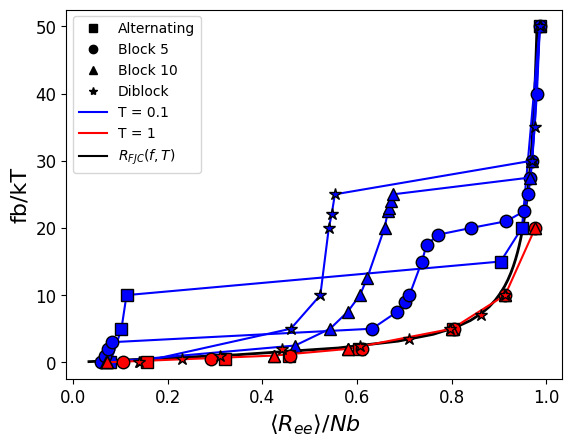

In [6]:
# All Sequences at Low T and High T
plt.plot(r, f, 'k-', linewidth = 2)

seq = ['Alternating', 'Block 5', 'Block 10', 'Diblock']
symbol = ['s','o','^',  '*']
i = 0
for item in ls:
    cgt = item[0]
    plt.plot(cgt.aveRee / 99, cgt.f / 0.1,symbol[i] + '-', markersize = 9, color = 'b', mec = 'black')
    i+=1

i = 0
index = [-3,-3,-2, -3]

cgt = ls[2][index[2]]
plt.plot(cgt.aveRee / 99, cgt.f, '^-', markersize = 9, color = 'r', mec = 'black')

for item in ls:
    cgt = item[index[i]]
    plt.plot(cgt.aveRee / 99, cgt.f, symbol[i], markersize = 9, color = 'r', mec = 'black')
    i+=1

from matplotlib.lines import Line2D

lowT = Line2D([0], [0], label = 'T = 0.1', color='blue')
highT = Line2D([0], [0], label = 'T = 1', color='red')
Theory = Line2D([0], [0], label = '$R_{FJC}(f, T)$', color='k')

circle = Line2D([0], [0], color='k', marker='s', linestyle='',
                          label='Alternating')
star = Line2D([0], [0], color='k', marker='o', linestyle='',
                          label='Block 5')
triangle = Line2D([0], [0], color='k', marker='^', linestyle='',
                          label='Block 10')
square = Line2D([0], [0], color='k', marker='*', linestyle='',
                          label='Diblock')

plt.legend(handles=[circle, star, triangle, square, lowT, highT, Theory])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$\langle R_{ee} \rangle / Nb$', fontsize = 16)
plt.ylabel('fb/kT', fontsize = 16)

## Free Energy

In [86]:
%store -r FE
%store -r FE_10

In [87]:
len(FE_10)

5

In [88]:
#Select the ones to plot
FE = FE[:-1]

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_28689/2111302046.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax[1].set_xlabel('Ree $(\sigma)$')
/tmp/ipykernel_28689/2111302046.py:26: SyntaxWarning: invalid escape sequence '\e'
  ax[0].set_ylabel('F$(\epsilon)$')


Text(37.722222222222214, 0.5, 'F$(\\epsilon)$')

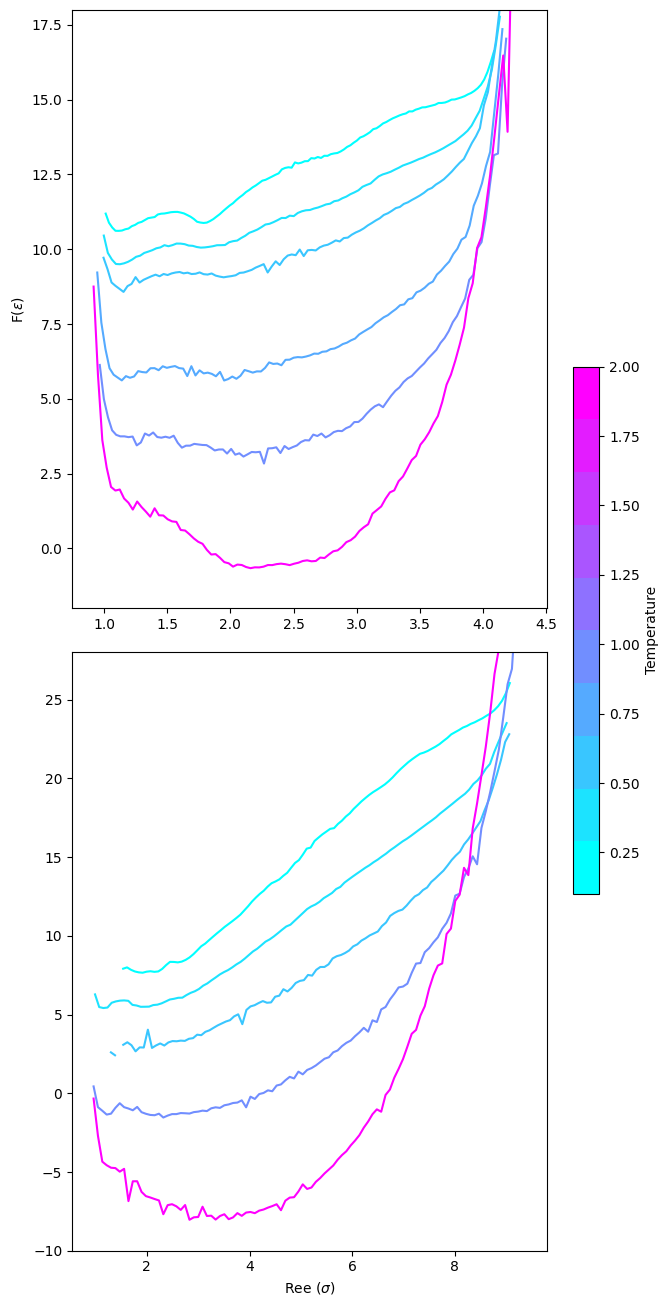

In [96]:
import matplotlib as mpl
fig, ax = plt.subplots(nrows = 2, ncols= 1, figsize = (6, 13))
fig.tight_layout()
cmap_FE = plt.get_cmap('cool', 10)
norm = mpl.colors.Normalize(0.1, 2)

#Block 5
c = np.array([-1, 0, 1, 1, 0, -3])-10
T = np.array([0.1, 0.3, 0.5, 0.75, 1, 2])
n_T = norm(T)
for i in range(6):
    ax[0].plot(FE[i][0],FE[i][1]-c[i], color = cmap_FE(n_T[i]))

#Block 10
c = [-7, -6, 0, -2, -5]
T = [0.1, 0.3, 0.5, 1, 2]
n_T = norm(T)
for i in range(5):
    ax[1].plot(FE_10[i][0],FE_10[i][1]-c[i], color = cmap_FE(n_T[i]))

sm = mpl.cm.ScalarMappable(cmap=cmap_FE, norm=norm)
plt.colorbar(sm, ax=ax, label='Temperature', fraction = 0.05)
ax[0].set_ylim(-2, 18)
ax[1].set_ylim(-10, 28)
ax[1].set_xlabel('Ree $(\sigma)$')
ax[0].set_ylabel('F$(\epsilon)$')

## Time Correlation (Modified)

In [8]:
import matplotlib.colors as mcolors
import matplotlib as mpl

In [7]:
#Get segmental end-to-end distance
def segRee(D, Blck, Atom_Type):
    Nf = D.shape[0]
    Mseg = 100//Blck*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,Blck,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

In [9]:
def AutoCorr(Rhp):
  c = []
  c.append(Rhp.var(axis = 0))
  Rbar = Rhp.mean(axis = 0)
  for t in range(1, Rhp.shape[0] // 10*9):
      ct = ((Rhp[:-t, :]-Rbar[np.newaxis, :])*(Rhp[t:, :]-Rbar[np.newaxis, :])).mean(axis = 0)
      c.append(ct)

  c = np.array(c)
  c = c.mean(axis = 1)
  return(c)

<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:52: SyntaxWarning: invalid escape sequence '\e'
C:\Users\20293\AppData\Local\Temp\ipykernel_85152\884368202.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)


Text(0, 0.5, "C(t-t')")

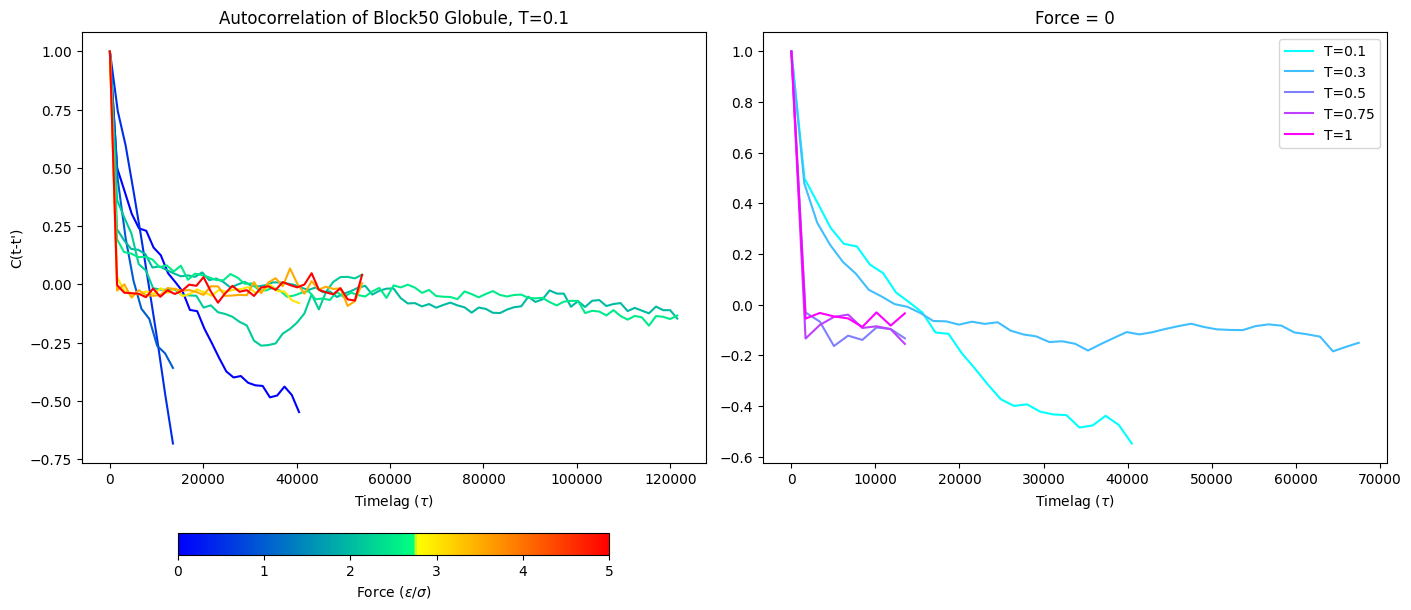

In [20]:
fig, ax = plt.subplots(nrows = 1, ncols= 2, figsize = (14, 6), layout='constrained')

#Block50
CGT01 = lsCGTBl50[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 55))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 45))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:6]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0],color = mymap(n_f[i]))
    i += 1
    
i = 6
for D in CGT01.ParsedRee[6:]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0],color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0].set_title('Autocorrelation of Block50 Globule, T=0.1')
ax[0].set_xlabel(r'Timelag ($\tau$)')

cmap_T = plt.get_cmap('cool', 5)
i = 0
for cgt in lsCGTBl50[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    c = AutoCorr(Rhp)
    # c = np.array([])
    # for i in range(Rhp.shape[1]):
    #     Rglob = Rhp[:, i]
    #     c = np.append(c, [np.correlate(Rglob, Rglob, mode = 'full')])
    maxt = c.shape[0]
    ax[1].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0], color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1].set_title('Force = 0')
ax[1].set_xlabel(r'Timelag ($\tau$)')
ax[1].legend(loc='upper right')

ax[0].set_ylabel('C(t-t\')')

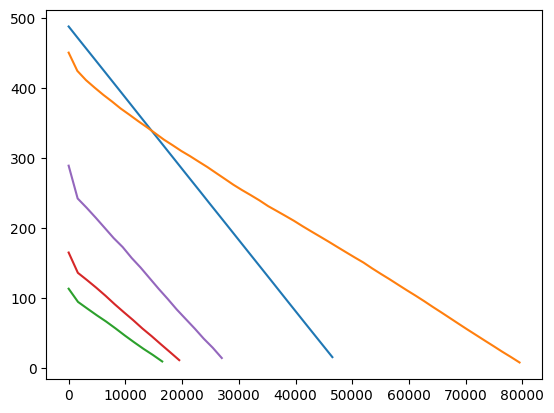

In [94]:
i = 0
for cgt in lsCGTBl50[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    c = []
    for j in range(Rhp.shape[1]):
        Rglob = Rhp[:, j]
        corr = np.correlate(Rglob, Rglob, mode = 'full')
        c.append([corr])
    c = np.array(c)[:, 0, :] #Not sure why there's an extra dimension
    c = c.mean(axis = 0)
    c = c[c.shape[0]//2:]
    maxt = c.shape[0]
    plt.plot(np.linspace(0, maxt, maxt)*3e5*0.005, c)
    i +=1

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\20293\AppData\Local\Temp\ipykernel_85152\350155301.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)


Text(0, 0.5, "C(t-t')")

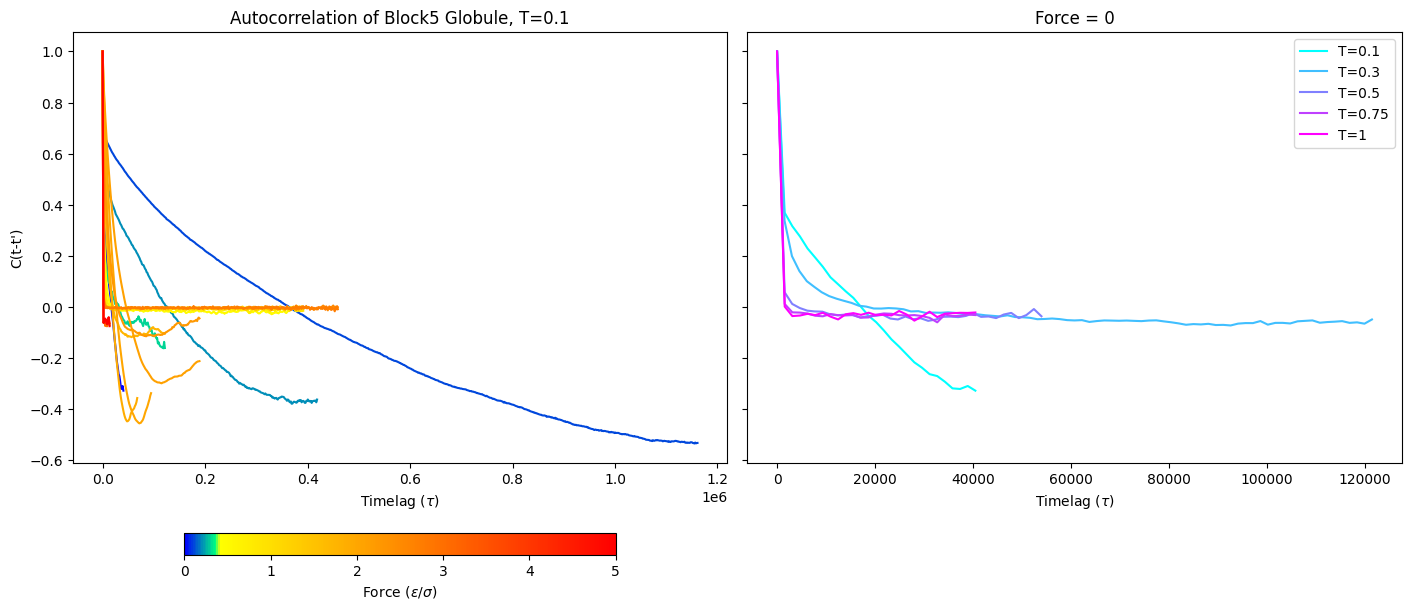

In [15]:
fig, ax = plt.subplots(nrows = 1, ncols= 2, figsize = (14, 6), layout='constrained', sharey=True)

#Block5
CGT01 = lsCGTBl5[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 8))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 92))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

i = 0
for D in CGT01.ParsedRee[0:4]:
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0], color = mymap(n_f[i]))
    i += 1
    
i = 4
for D in CGT01.ParsedRee[4:]:
    
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0], color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0].set_title('Autocorrelation of Block5 Globule, T=0.1')
ax[0].set_xlabel(r'Timelag ($\tau$)')

cmap_T = plt.get_cmap('cool', 5)
i = 0
for cgt in lsCGTBl5[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[1].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1].set_title('Force = 0')
ax[1].set_xlabel(r'Timelag ($\tau$)')
ax[1].legend(loc='upper right')

ax[0].set_ylabel('C(t-t\')')

In [1]:
fig, ax = plt.subplots(nrows = 1, ncols= 2, figsize = (14, 6), layout='constrained', sharey=True)

#Block10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 25))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 975))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:1]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0], color = mymap(n_f[i]))
    i += 1
    
i = 1
for D in CGT01.ParsedRee[1:]:
    
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[0].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0], color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0].set_title('Autocorrelation of Block10 Globule, T=0.1')
ax[0].set_xlabel(r'Timelag ($\tau$)')

cmap_T = plt.get_cmap('cool', 5)
i = 0
for cgt in lsCGTBl10[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    c = AutoCorr(Rhp)
    maxt = c.shape[0]
    ax[1].plot(np.linspace(0, maxt, maxt)*3e5*0.005, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1].set_title('Force = 0')
ax[1].set_xlabel(r'Timelag ($\tau$)')
ax[1].legend(loc='upper right')

ax[0].set_ylabel('C(t-t\')')

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\20293\AppData\Local\Temp\ipykernel_85152\890251456.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
C:\Users\20293\AppData\Local\Temp\ipykernel_85152\890251456.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)


NameError: name 'plt' is not defined

In [263]:
len(CGT01.ParsedRee)

19

In [268]:
n_f[18]

np.float64(1.0)

## Time Correlation

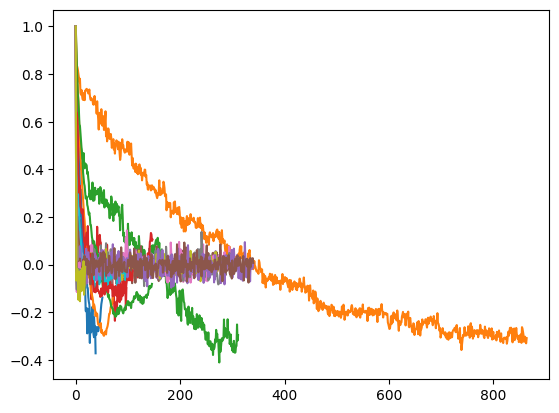

In [397]:
for D in lsCGTBl5[0].ParsedRee:
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = Rhp.mean(axis = 0)
    dR = Rhp-mean[np.newaxis, :]
    c=[]
    c.append(Rhp.var(axis = 0))
    for t in range(1, Rhp.shape[0] // 10*9):
      ct = (dR[:-t, :]*dR[t:, :]).mean(axis = 0)
      c.append(ct)
    c = (dR*dR[0,:]).mean(axis = 1)
    plt.plot(c/c[0])

In [377]:
print(mean)
Rhp.mean(axis = 0)

1.7617984257283383


array([1.78329207, 1.78226546, 1.77873996, 1.7915848 , 1.77819089,
       1.74475861, 1.77387571, 1.77868444, 1.74921766, 1.75563446,
       1.75743143, 1.76694529, 1.76708651, 1.76087598, 1.76932914,
       1.78504223, 1.75841346, 1.75209523, 1.770434  , 1.78183929,
       1.7384719 , 1.74561587, 1.77642883, 1.75866045, 1.76880454,
       1.75766666, 1.77839338, 1.75688158, 1.73109691, 1.76837798,
       1.73718175, 1.72495932, 1.77050133, 1.75616025, 1.72228365,
       1.75428549, 1.75635893, 1.7552843 , 1.77531102, 1.78564794,
       1.76799796, 1.77981921, 1.76446733, 1.76858463, 1.75854761,
       1.73601989, 1.75489644, 1.7509753 , 1.77562807, 1.75504642,
       1.75960288, 1.75700622, 1.74485112, 1.75224662, 1.78537783,
       1.77960083, 1.76675614, 1.77328949, 1.77423499, 1.78697896,
       1.76106852, 1.71803606, 1.76776864, 1.75253623, 1.7427525 ,
       1.71925516, 1.73231448, 1.76211647, 1.77124586, 1.75729406,
       1.74928943, 1.75270835, 1.76185779, 1.77888247, 1.78305

<>:55: SyntaxWarning: invalid escape sequence '\e'
<>:111: SyntaxWarning: invalid escape sequence '\e'
<>:167: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\e'
<>:111: SyntaxWarning: invalid escape sequence '\e'
<>:167: SyntaxWarning: invalid escape sequence '\e'
C:\Users\20293\AppData\Local\Temp\ipykernel_21560\1851035125.py:55: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0,0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
C:\Users\20293\AppData\Local\Temp\ipykernel_21560\1851035125.py:111: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0,1], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
C:\Users\20293\AppData\Local\Temp\ipykernel_21560\1851035125.py:167: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(sm, ax=ax[0,2], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)


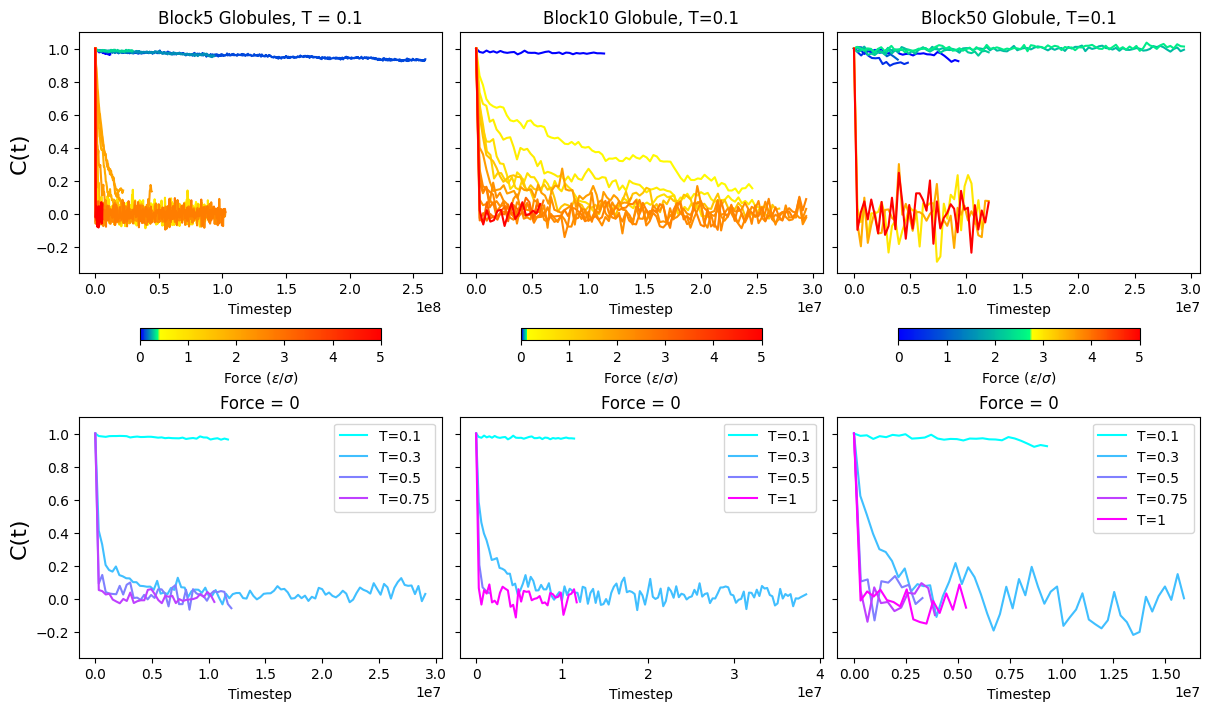

In [360]:
fig, ax = plt.subplots(nrows = 2, ncols= 3, figsize = (12, 7), sharey=True, layout='constrained')

CGT01 = lsCGTBl5[0]
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
colors1 = plt.cm.winter(np.linspace(0, 1, 8))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 92))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

i = 0
for D in CGT01.ParsedRee[0:4]:
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

i = 4
for D in CGT01.ParsedRee[4:]:
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,
    5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0,0], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0,0].set_title('Block5 Globules, T = 0.1')
ax[0,0].set_xlabel('Timestep')
ax[0,0].set_ylabel('C(t)', fontsize = 16)

#Block10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 25))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 975))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:1]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

i = 1
for D in CGT01.ParsedRee[1:]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1


sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 5), cmap=mymap)
plt.colorbar(sm, ax=ax[0,1], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0,1].set_title('Block10 Globule, T=0.1')
ax[0,1].set_xlabel('Timestep')

#Block50
CGT01 = lsCGTBl50[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 55))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 45))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:6]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = mymap(n_f[i]))
    i += 1
    
i = 6
for D in CGT01.ParsedRee[6:]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0,2], label = 'Force ($\epsilon/\sigma$)', orientation = 'horizontal', fraction = 0.05)
ax[0,2].set_title('Block50 Globule, T=0.1')
ax[0,2].set_xlabel('Timestep')

#Second row
cmap_T = plt.get_cmap('cool', 5)

i = 0
for cgt in lsCGTBl5[0:4]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1, 0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,0].set_title('Force = 0')
ax[1,0].set_xlabel('Timestep')
ax[1,0].set_ylabel('C(t)', fontsize = 16)
ax[1,0].legend(loc='upper right')

i = 0
for cgt in lsCGTBl10[0:4]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    
    if i == 2:
        i += 2
    else:
        i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,1].set_title('Force = 0')
ax[1,1].set_xlabel('Timestep')
ax[1,1].legend(loc='upper right')
ax[1,1].legend(loc='upper right')

i = 0
for cgt in lsCGTBl50[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,2].set_title('Force = 0')
ax[1,2].set_xlabel('Timestep')
ax[1,2].legend(loc='upper right')

## Hydrophobic Ree

### Modified Plots

Text(0, 0.5, 'P(R)')

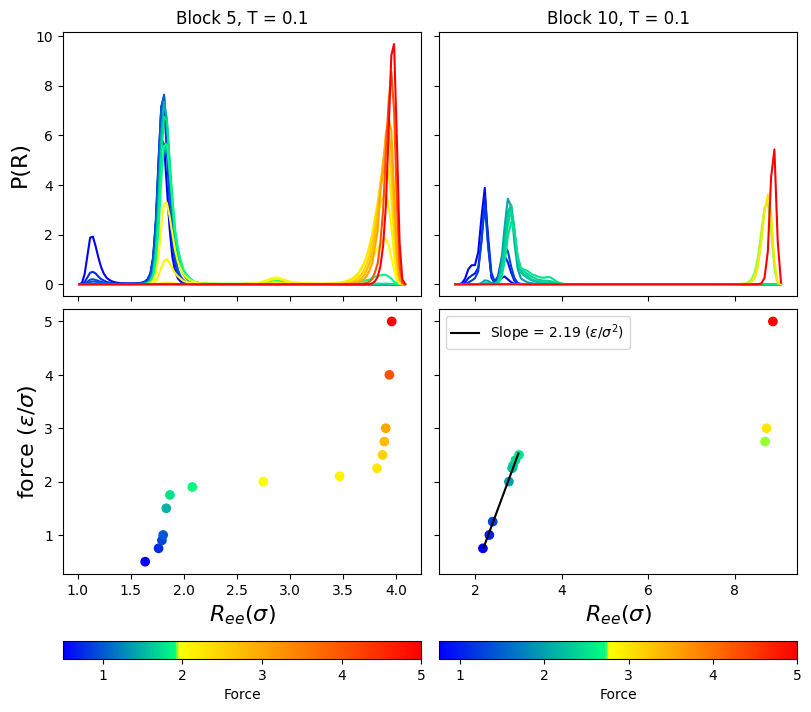

In [62]:
fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize = (8, 7), sharey='row', sharex='col', layout='constrained')

#Block 
colors1 = plt.cm.winter(np.linspace(0, 1, 32))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 68))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.5, 5)

CGT01 = lsCGTBl5[0]
Hph = []
for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    Hph.append(D.mean())

elastic = Hph[0:6]
modulus, intercept = plt.polyfit(elastic, CGT01.f[4:10], 1)

ax[1,0].scatter(Hph, CGT01.f[4:], color = mymap(norm(CGT01.f[4:])))
x = np.array([1.75, 1.88])
# ax[1,0].plot(x, (x*modulus+intercept)/0.1, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,0].set_xlabel('$R_{ee} (\sigma)$', fontsize = 16)
ax[1,0].set_ylabel('force ($\epsilon/\sigma$)', fontsize = 16)
# ax[1,0].legend()

f_N = norm(CGT01.f[4:])

for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    rang = np.linspace(1, 4.1, 121)
    prob, xh = np.histogram(D,bins=rang, density=True)
    xh = (xh[:-1] + xh[1:]) / 2
    ax[0,0].plot(xh, prob, color = mymap(f_N[i-4]))
    
sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,0], label='Force', orientation = 'horizontal')

#Block 10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 47))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 53))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.75, 5)
f_N = norm(CGT01.f[3:])

Hph = []
for i in range(3, 14):
    D = segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten()
    Hph.append(D.mean())
    
elastic = Hph[0:8]
modulus, intercept = plt.polyfit(elastic, CGT01.f[3:11], 1)

ax[1,1].scatter(Hph, CGT01.f[3:], color = mymap(norm(CGT01.f[3:])))
x = np.array([2.2, 3])
ax[1,1].plot(x, x*modulus+intercept, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,1].set_xlabel('$R_{ee} (\sigma)$', fontsize = 16)
ax[1,1].legend()

for i in range(3, 14):
    rang = np.linspace(1.5, 9.11, 101)
    prob = np.histogram(segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten(),bins=rang, density=True)[0]
    xh = (rang[:-1]+rang[1:])/2
    ax[0, 1].plot(xh, prob, color = mymap(f_N[i-3]))
plt.legend()

sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,1], label='Force', orientation = 'horizontal')

ax[0,0].set_title('Block 5, T = 0.1')
ax[0,1].set_title('Block 10, T = 0.1')
ax[0,0].set_ylabel('P(R)', fontsize = 16)

### Original Plots

Text(0, 0.5, 'P(R)')

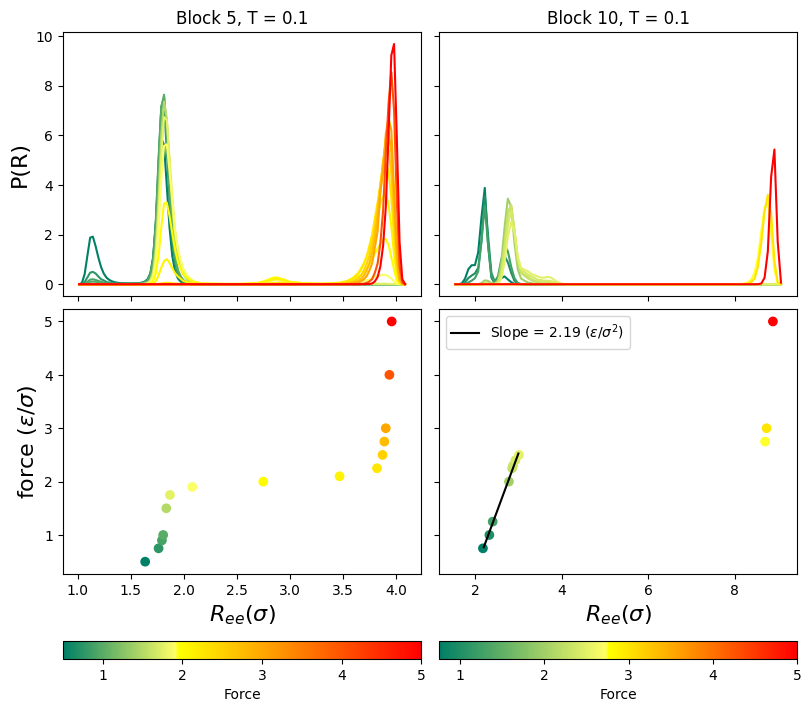

In [160]:
fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize = (8, 7), sharey='row', sharex='col', layout='constrained')

#Block 
colors1 = plt.cm.summer(np.linspace(0, 1, 32))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 68))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.5, 5)

CGT01 = lsCGTBl5[0]
Hph = []
for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    Hph.append(D.mean())

elastic = Hph[0:6]
modulus, intercept = plt.polyfit(elastic, CGT01.f[4:10], 1)

ax[1,0].scatter(Hph, CGT01.f[4:], color = mymap(norm(CGT01.f[4:])))
x = np.array([1.75, 1.88])
# ax[1,0].plot(x, (x*modulus+intercept)/0.1, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,0].set_xlabel('$R_{ee} (\sigma)$', fontsize = 16)
ax[1,0].set_ylabel('force ($\epsilon/\sigma$)', fontsize = 16)
# ax[1,0].legend()

f_N = norm(CGT01.f[4:])

for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    rang = np.linspace(1, 4.1, 121)
    prob, xh = np.histogram(D,bins=rang, density=True)
    xh = (xh[:-1] + xh[1:]) / 2
    ax[0,0].plot(xh, prob, color = mymap(f_N[i-4]))
    
sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,0], label='Force', orientation = 'horizontal')

#Block 10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.summer(np.linspace(0, 1, 47))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 53))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.75, 5)
f_N = norm(CGT01.f[3:])

Hph = []
for i in range(3, 14):
    D = segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten()
    Hph.append(D.mean())
    
elastic = Hph[0:8]
modulus, intercept = plt.polyfit(elastic, CGT01.f[3:11], 1)

ax[1,1].scatter(Hph, CGT01.f[3:], color = mymap(norm(CGT01.f[3:])))
x = np.array([2.2, 3])
ax[1,1].plot(x, x*modulus+intercept, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,1].set_xlabel('$R_{ee} (\sigma)$', fontsize = 16)
ax[1,1].legend()

for i in range(3, 14):
    rang = np.linspace(1.5, 9.11, 101)
    prob = np.histogram(segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten(),bins=rang, density=True)[0]
    xh = (rang[:-1]+rang[1:])/2
    ax[0, 1].plot(xh, prob, color = mymap(f_N[i-3]))
plt.legend()

sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,1], label='Force', orientation = 'horizontal')

ax[0,0].set_title('Block 5, T = 0.1')
ax[0,1].set_title('Block 10, T = 0.1')
ax[0,0].set_ylabel('P(R)', fontsize = 16)

In [158]:
CGT01.f[1:]

array([0.25, 0.5 , 0.75, 1.  , 1.25, 2.  , 2.25, 2.3 , 2.4 , 2.5 , 2.75,
       3.  , 5.  ])